In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import PowerTransformer

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 读取数据
df = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\完整眼动数据分析\眼动数据格式对齐后文件.xlsx')
df

,阶段,AOI转换次数,静态注释熵(SGE),眼跳注视熵(GTE),组别,性别,受试者,飞行天数
0,起飞,13.0,1.398246,0.507883,Alcohol,女,付瑞晗,1
1,转弯,4.0,0.890165,0.212143,Alcohol,女,付瑞晗,1
2,转弯,10.0,0.923579,0.399419,Alcohol,女,付瑞晗,1
3,巡航,18.0,1.012136,0.642191,Alcohol,女,付瑞晗,1
4,转弯,12.0,1.664170,0.542276,Alcohol,女,付瑞晗,1
...,...,...,...,...,...,...,...,...
1450,转弯,38.0,1.856486,0.533725,Control,男,郭浚杰,7
1451,巡航,38.0,2.609610,0.506751,Control,男,郭浚杰,7
1452,转弯,31.0,2.074730,0.374989,Control,男,郭浚杰,7
1453,转弯,0.0,0.654472,0.000000,Control,男,郭浚杰,7


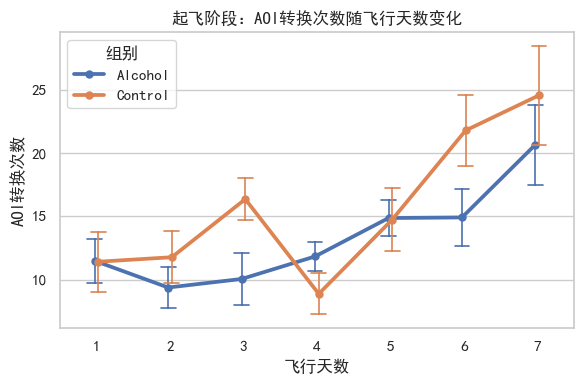

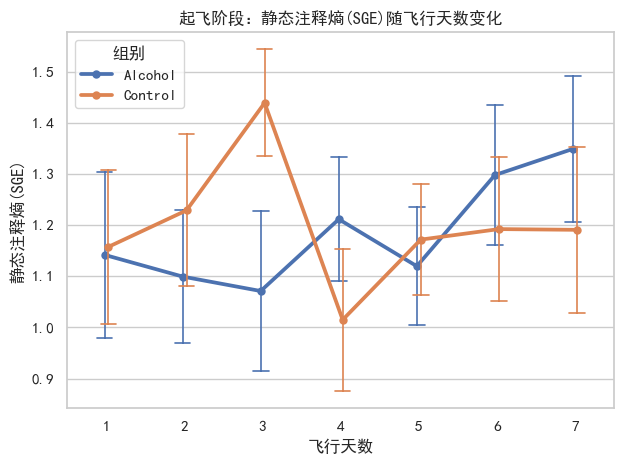

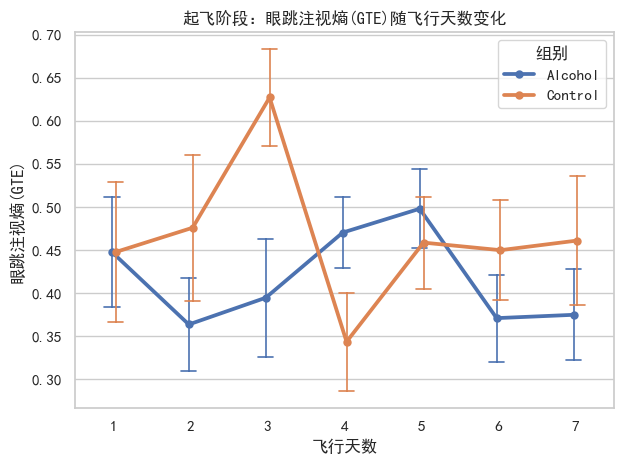

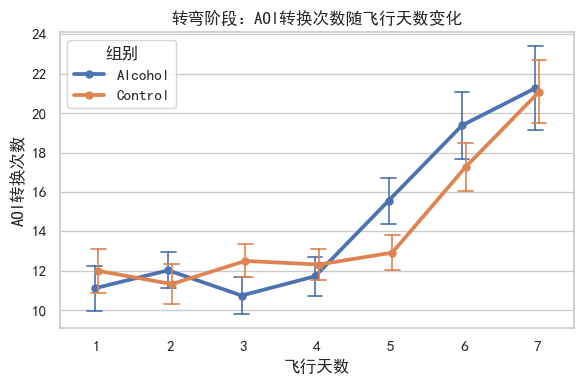

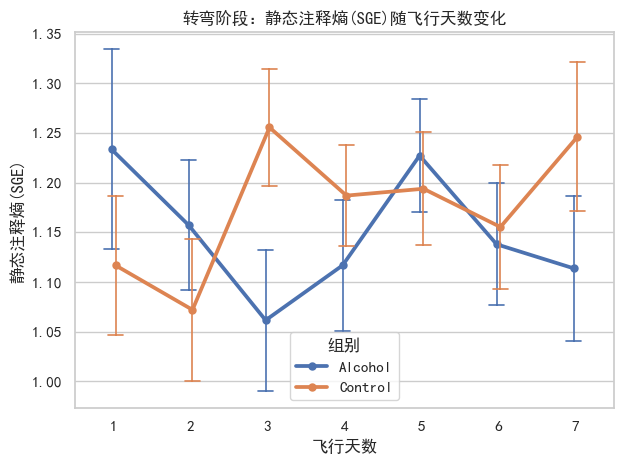

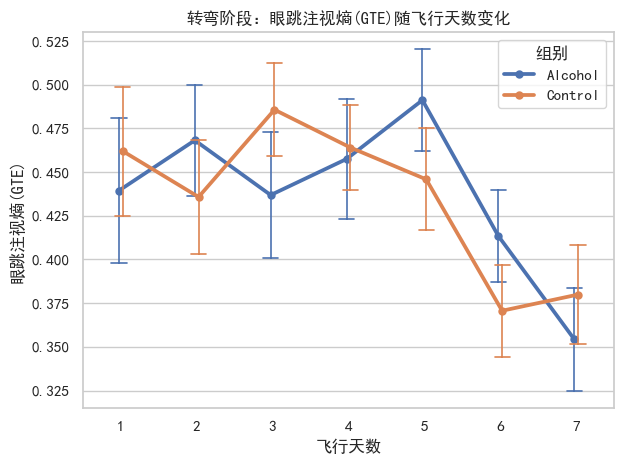

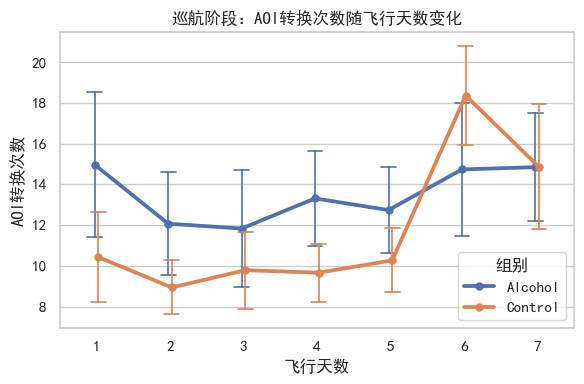

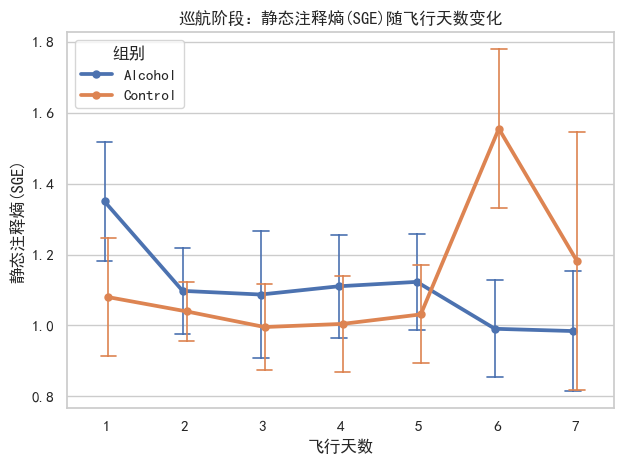

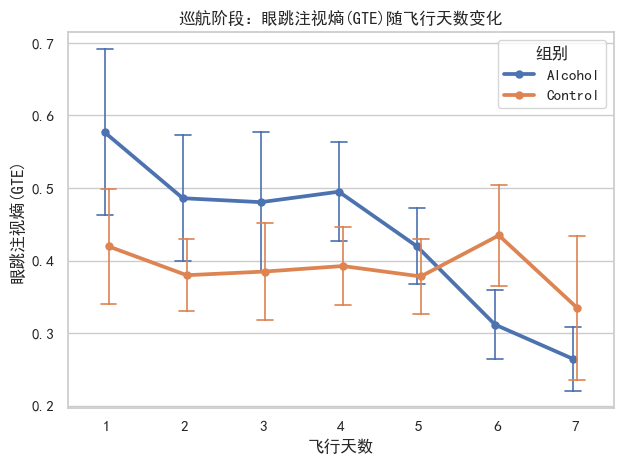

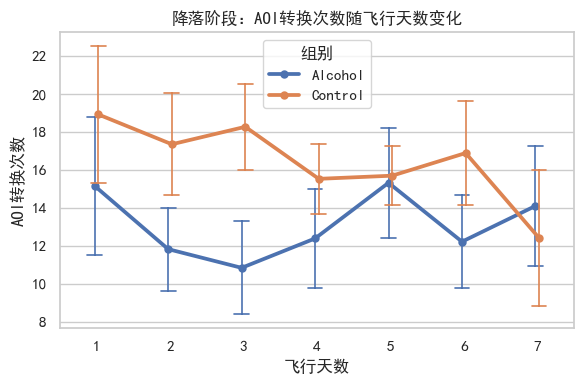

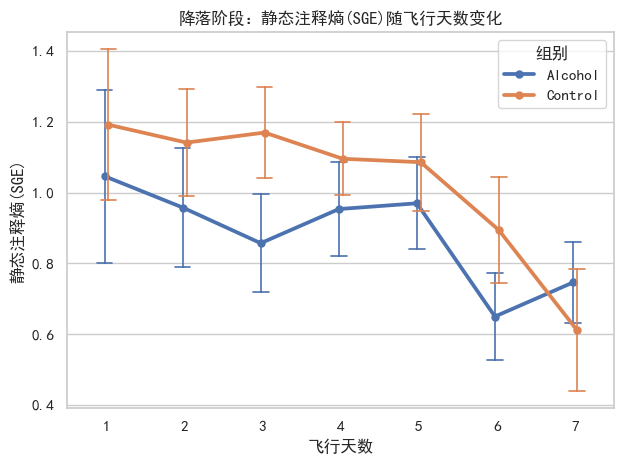

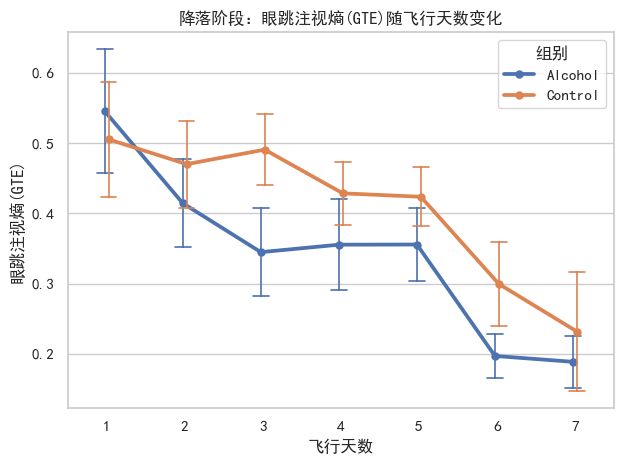

In [3]:
# 设定绘图风格
sns.set(style="whitegrid", font="SimHei")  # 支持中文显示

# 三个阶段
phases = df["阶段"].unique()
label = 'AOI转换次数'
# label = '静态注释熵(SGE)'
# label = '眼跳注视熵(GTE)'
labels = ['AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)']
# 建立图表
for phase in phases:
    plt.figure(figsize=(6, 4))

    # if phase != "降落":
    #     continue
    # 筛选该阶段数据
    sub_df = df[df["阶段"] == phase]
    for label in labels:
        sns.pointplot(
            data=sub_df,
            x="飞行天数",
            y=label,
            hue="组别",
            # errorbar=("ci", 95), # 误差线显示 95% 置信区间 # 或 ("se", 1)
            errorbar=("se", 1),  # 画标准误 误差线显示 ±1 标准误
            dodge=True,
            join=True,
            capsize=0.2,  # 控制小横线长度 (相对比例)
            errwidth=1.2,  # 误差线粗细，可调
            markersize=4
        )

        plt.title(f"{phase}阶段：{label}随飞行天数变化")
        plt.xlabel("飞行天数")
        plt.ylabel(label)
        plt.legend(title="组别")
        plt.tight_layout()
        plt.show()
